# Alternative Data Evaluation: DeFi TVL Case Study

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: See Section 4.4 for alternative data due diligence concepts

## Purpose

This notebook demonstrates a rigorous alternative data evaluation framework using
**real data**: DeFi Llama's Total Value Locked (TVL) metrics. Rather than theoretical
checklists, we compute actual signal quality, assess real data gaps, and calculate
whether this free dataset justifies integration into a trading pipeline.

## Learning Objectives

After completing this notebook, you will be able to:
- Apply a 4-dimension evaluation framework to real alternative data
- Calculate Information Coefficients (IC) and signal decay empirically
- Assess data quality: coverage, gaps, methodology transparency
- Evaluate legal/compliance considerations for blockchain data
- Compute break-even alpha requirements for data costs

## The Evaluation Framework

This notebook implements a **four-gate** evaluation (Signal, Data, Legal, Commercial). In the
chapter text, these gates expand into a seven-check rubric (uniqueness, decay, quality, coverage,
latency, legal, engineering/economics). The goal is to avoid false precision: failing any hard
gate (PIT/legal) should block integration regardless of a "score."

| Gate | Key Questions |
|------|---------------|
| **Signal** | Does it predict returns? How quickly does the signal decay? |
| **Data** | Coverage? Gaps? Methodology? Point-in-time available? |
| **Legal** | Data source legality? MNPI risk? Usage restrictions? |
| **Commercial** | Cost vs value? Build vs buy? API reliability? |

## Cross-References

- **Data Source**: [`09_onchain_fundamentals`](09_onchain_fundamentals.ipynb) loads the TVL data
- **Framework**: This evaluation methodology applies to ANY alternative dataset
- **Downstream**: Use findings to decide whether to integrate into Chapter 8 features

In [1]:
"""Alternative Data Evaluation: DeFi TVL Case Study — measure four evaluation dimensions on a real alt-data feed."""

import warnings

warnings.filterwarnings("ignore")

from dataclasses import dataclass

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_coingecko_ohlcv, load_defillama_chain_tvl
from utils.style import COLORS

print("Alternative Data Evaluation: DeFi TVL Case Study")

Alternative Data Evaluation: DeFi TVL Case Study


In [2]:
# Production defaults — Papermill injects overrides for CI

---

## Section 1: Load the Data

We evaluate whether DeFi TVL predicts ETH returns. Both feeds come
from the canonical on-chain downloader — run once, then work offline:

```bash
python data/crypto/onchain/download.py
```

Loaders raise `DataNotFoundError` with the exact command if an
expected parquet is missing, so there is no hidden network path.

In [3]:
tvl_data = load_defillama_chain_tvl("total").with_columns((pl.col("tvl_usd") / 1e9).alias("tvl_bn"))

# CoinGecko returns two rows for the download day (an intraday roll-up
# and a daily summary); collapse to one row per date by taking the last
# observation. Without this, the inner join below would propagate the
# duplicate into every downstream feature.
eth_data = (
    load_coingecko_ohlcv("ethereum")
    .select(pl.col("timestamp"), pl.col("price_usd").alias("eth_price"))
    .group_by("timestamp")
    .agg(pl.col("eth_price").last())
    .sort("timestamp")
)

print(
    f"TVL observations: {len(tvl_data):,} ({tvl_data['timestamp'].min()} → {tvl_data['timestamp'].max()})"
)
print(
    f"ETH observations: {len(eth_data):,} ({eth_data['timestamp'].min()} → {eth_data['timestamp'].max()})"
)

# CoinGecko free tier is 365 days, so the merge is bounded by ETH coverage.
data = tvl_data.join(eth_data, on="timestamp", how="inner").sort("timestamp")
print(
    f"Combined dataset: {data.shape}, range: {data['timestamp'].min()} → {data['timestamp'].max()}"
)
data.tail(5)

TVL observations: 3,139 (2017-09-27 → 2026-05-01)
ETH observations: 365 (2025-05-02 → 2026-05-01)
Combined dataset: (365, 4), range: 2025-05-02 → 2026-05-01


timestamp,tvl_usd,tvl_bn,eth_price
date,i64,f64,f64
2026-04-27,85237200680,85.237201,2369.743029
2026-04-28,83714613526,83.714614,2299.770459
2026-04-29,83282116410,83.282116,2288.044927
2026-04-30,83484152685,83.484153,2253.458358
2026-05-01,84621565953,84.621566,2294.157168


---

## Section 2: Signal Quality Assessment

The most important question: **Does this data predict returns?**

We'll calculate:
- Information Coefficient (IC): Correlation between signal and forward returns
- Signal decay: How quickly does predictive power diminish?
- Regime analysis: Does the signal work in different market conditions?

In [4]:
# Create features and forward returns
analysis = (
    data.with_columns(
        [
            # TVL momentum signals
            pl.col("tvl_bn").pct_change(7).alias("tvl_growth_7d"),
            pl.col("tvl_bn").pct_change(30).alias("tvl_growth_30d"),
            (
                (pl.col("tvl_bn") - pl.col("tvl_bn").rolling_mean(90))
                / pl.col("tvl_bn").rolling_std(90)
            ).alias("tvl_zscore"),
            # Forward returns at various horizons
            pl.col("eth_price").pct_change(7).shift(-7).alias("fwd_return_7d"),
            pl.col("eth_price").pct_change(14).shift(-14).alias("fwd_return_14d"),
            pl.col("eth_price").pct_change(30).shift(-30).alias("fwd_return_30d"),
            pl.col("eth_price").pct_change(60).shift(-60).alias("fwd_return_60d"),
        ]
    )
    .filter(pl.col("tvl_growth_30d").is_not_null())
    .filter(pl.col("fwd_return_30d").is_not_null())
)

print(f"Analysis dataset: {analysis.shape}")

Analysis dataset: (305, 11)


Classical t-statistics are not valid here: forward-return horizons
overlap by construction (every 30-day forward return shares 29 days
with the next), inducing strong autocorrelation that inflates naive
significance. The ICs below are *screening diagnostics*, not hypothesis
tests. For inference, use HAC / Newey-West standard errors or a block
bootstrap on non-overlapping samples.

In [5]:
signals = ["tvl_growth_7d", "tvl_growth_30d", "tvl_zscore"]
horizons = ["fwd_return_7d", "fwd_return_14d", "fwd_return_30d", "fwd_return_60d"]

ic_long = pl.concat(
    [
        analysis.select(
            pl.lit(s).alias("signal"),
            pl.lit(h).alias("horizon"),
            pl.corr(s, h).alias("IC"),
            pl.col(s).is_not_null().sum().alias("n_obs"),
        )
        for s in signals
        for h in horizons
    ]
)
ic_df = ic_long.filter(pl.col("n_obs") > 30)
ic_df

signal,horizon,IC,n_obs
str,str,f64,u32
"""tvl_growth_7d""","""fwd_return_7d""",0.029257,305
"""tvl_growth_7d""","""fwd_return_14d""",0.114032,305
"""tvl_growth_7d""","""fwd_return_30d""",0.084906,305
"""tvl_growth_7d""","""fwd_return_60d""",0.025952,305
"""tvl_growth_30d""","""fwd_return_7d""",0.090129,305
…,…,…,…
"""tvl_growth_30d""","""fwd_return_60d""",-0.003566,305
"""tvl_zscore""","""fwd_return_7d""",0.070669,246
"""tvl_zscore""","""fwd_return_14d""",0.070308,246


In [6]:
# Create IC heatmap (signals × horizons)
# Reshape data for heatmap
signal_order = ["tvl_growth_7d", "tvl_growth_30d", "tvl_zscore"]
horizon_order = ["fwd_return_7d", "fwd_return_14d", "fwd_return_30d", "fwd_return_60d"]

# Build matrix
ic_matrix = []
for signal in signal_order:
    row = []
    for horizon in horizon_order:
        ic_val = ic_df.filter((pl.col("signal") == signal) & (pl.col("horizon") == horizon))[
            "IC"
        ].to_list()
        row.append(ic_val[0] if ic_val else 0)
    ic_matrix.append(row)

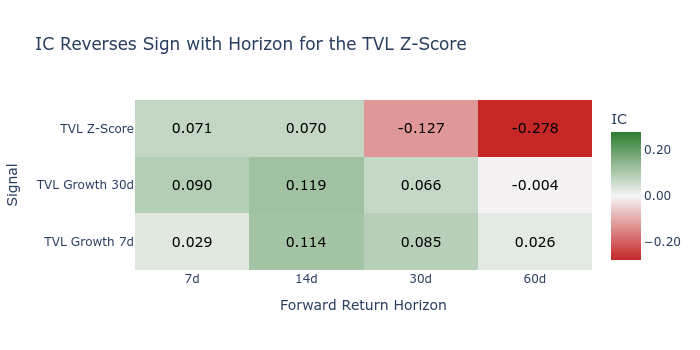

In [7]:
# Clean labels
signal_labels = ["TVL Growth 7d", "TVL Growth 30d", "TVL Z-Score"]
horizon_labels = ["7d", "14d", "30d", "60d"]

# Create heatmap with custom colorscale
fig = go.Figure(
    data=go.Heatmap(
        z=ic_matrix,
        x=horizon_labels,
        y=signal_labels,
        colorscale=[
            [0.0, "#C62828"],  # negative IC (red)
            [0.5, "#F5F5F5"],  # zero IC (neutral)
            [1.0, "#2E7D32"],  # positive IC (green)
        ],
        zmid=0,  # Center colorscale at 0
        text=[[f"{v:.3f}" for v in row] for row in ic_matrix],
        texttemplate="%{text}",
        textfont={"size": 14, "color": "black"},
        colorbar=dict(title="IC", tickformat=".2f"),
    )
)

fig.update_layout(
    title="IC Reverses Sign with Horizon for the TVL Z-Score",
    xaxis_title="Forward Return Horizon",
    yaxis_title="Signal",
    height=350,
    template="plotly_white",
)
fig.show()

In [8]:
ic_df.sort(pl.col("IC").abs(), descending=True).head(3)

signal,horizon,IC,n_obs
str,str,f64,u32
"""tvl_zscore""","""fwd_return_60d""",-0.277553,246
"""tvl_zscore""","""fwd_return_30d""",-0.127472,246
"""tvl_growth_30d""","""fwd_return_14d""",0.118762,305


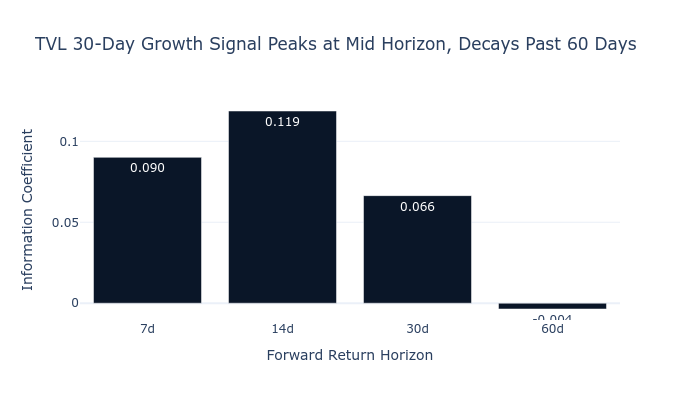

In [9]:
# Visualize IC by horizon (signal decay)
pivot_data = ic_df.filter(pl.col("signal") == "tvl_growth_30d")

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=[h.replace("fwd_return_", "") for h in pivot_data["horizon"]],
        y=pivot_data["IC"],
        text=[f"{ic:.3f}" if ic is not None else "N/A" for ic in pivot_data["IC"]],
        textposition="auto",
        marker_color=COLORS["blue"],
    )
)

fig.update_layout(
    title="TVL 30-Day Growth Signal Peaks at Mid Horizon, Decays Past 60 Days",
    xaxis_title="Forward Return Horizon",
    yaxis_title="Information Coefficient",
    height=400,
    template="plotly_white",
)
fig.show()

### Rolling IC stability

A point estimate hides regime dependence. The next cell rolls a
180-day window across the joined sample to expose how variable the
IC actually is.

In [10]:
rolling_window = 180
rolling_ic_df = pl.DataFrame(
    {
        "timestamp": analysis["timestamp"][rolling_window:],
        "rolling_ic": [
            analysis.slice(i - rolling_window, rolling_window)
            .select(pl.corr("tvl_growth_30d", "fwd_return_30d"))
            .item()
            for i in range(rolling_window, len(analysis))
        ],
    }
).filter(pl.col("rolling_ic").is_not_null())

ic_mean = rolling_ic_df["rolling_ic"].mean()
ic_std = rolling_ic_df["rolling_ic"].std()
ic_positive_pct = (rolling_ic_df["rolling_ic"] > 0).mean()

rolling_ic_df.select(
    pl.lit(rolling_window).alias("window_days"),
    pl.lit(len(rolling_ic_df)).alias("n_windows"),
    pl.col("rolling_ic").mean().round(3).alias("mean_ic"),
    pl.col("rolling_ic").std().round(3).alias("std_ic"),
    (pl.col("rolling_ic") > 0).mean().round(3).alias("share_positive"),
)

window_days,n_windows,mean_ic,std_ic,share_positive
i32,i32,f64,f64,f64
180,125,-0.11,0.357,0.488


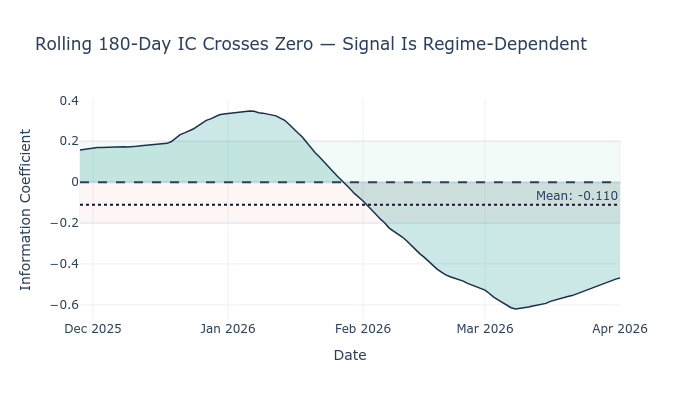

In [11]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=rolling_ic_df["timestamp"],
        y=rolling_ic_df["rolling_ic"],
        name="Rolling IC",
        line=dict(color=COLORS["slate"], width=1.5),
        fill="tozeroy",
        fillcolor="rgba(4, 138, 129, 0.2)",
    )
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.add_hline(
    y=ic_mean,
    line_dash="dot",
    line_color=COLORS["blue"],
    annotation_text=f"Mean: {ic_mean:.3f}",
)

# Add bands for positive/negative regions
fig.add_hrect(y0=0, y1=0.2, fillcolor=COLORS["positive"], opacity=0.05)
fig.add_hrect(y0=-0.2, y1=0, fillcolor=COLORS["negative"], opacity=0.05)

fig.update_layout(
    title="Rolling 180-Day IC Crosses Zero — Signal Is Regime-Dependent",
    xaxis_title="Date",
    yaxis_title="Information Coefficient",
    height=400,
    template="plotly_white",
)
fig.show()

---

## Section 3: Data Quality Assessment

Beyond signal quality, we need to assess the data itself:
- **Coverage**: What time period? What assets/chains?
- **Gaps**: Missing data? Inconsistencies?
- **Methodology**: How is TVL calculated? What's included/excluded?
- **Point-in-Time**: Can we reconstruct historical views without lookahead bias?

DefiLlama's series begins in September 2017 when total TVL was a few
hundred thousand dollars; once we restrict to the post-2019 era when
TVL exceeded \$100M the early-curve noise drops out and the gap /
extreme-move statistics describe the modern regime that any signal
would actually trade.

In [12]:
tvl_modern = tvl_data.filter(pl.col("tvl_bn") >= 0.1).sort("timestamp")
date_gaps = tvl_modern.with_columns(
    (pl.col("timestamp") - pl.col("timestamp").shift(1)).dt.total_days().alias("days_gap")
)
gaps = date_gaps.filter(pl.col("days_gap") > 1)
extreme_changes = tvl_modern.with_columns(
    pl.col("tvl_bn").pct_change().alias("daily_change")
).filter(pl.col("daily_change").abs() > 0.20)

tvl_modern.select(
    pl.col("timestamp").min().alias("start"),
    pl.col("timestamp").max().alias("end"),
    pl.len().alias("n_obs"),
    pl.col("tvl_bn").min().round(2).alias("min_bn"),
    pl.col("tvl_bn").max().round(1).alias("max_bn"),
    pl.col("tvl_bn").mean().round(1).alias("mean_bn"),
    pl.lit(tvl_modern["tvl_usd"].null_count()).alias("nulls"),
    pl.lit(len(gaps)).alias("date_gaps"),
    pl.lit(len(extreme_changes)).alias("daily_moves_gt_20pct"),
)

start,end,n_obs,min_bn,max_bn,mean_bn,nulls,date_gaps,daily_moves_gt_20pct
date,date,u32,f64,f64,f64,i32,i32,i32
2019-01-04,2026-05-01,2675,0.11,177.5,64.9,0,0,7


A weighted composite is a teaching scaffold, not a calibrated metric:
the weights below come from the chapter rubric, and the absolute
number is meaningful only relative to other datasets scored the same
way. Coverage is bounded at 25 because longer-than-five-year history
adds little marginal evidence for a strategy with a one-year holdout.
The PIT term gets 15 points because backfill risk is the single most
common path to inflated alt-data backtests.

In [13]:
@dataclass
class DataQualityMetrics:
    coverage_years: float
    missing_pct: float
    gap_days: int
    extreme_moves_pct: float
    methodology_transparent: bool
    pit_available: bool

    @property
    def score(self) -> float:
        return min(
            100.0,
            min(25.0, self.coverage_years * 5)
            + max(0.0, 25.0 - self.missing_pct * 100)
            + max(0.0, 20.0 - self.extreme_moves_pct * 100)
            + (15 if self.methodology_transparent else 0)
            + (15 if self.pit_available else 0),
        )


coverage_years = (tvl_modern["timestamp"].max() - tvl_modern["timestamp"].min()).days / 365
missing_pct = tvl_modern["tvl_usd"].null_count() / len(tvl_modern)
extreme_pct = len(extreme_changes) / len(tvl_modern)

quality = DataQualityMetrics(
    coverage_years=coverage_years,
    missing_pct=missing_pct,
    gap_days=int(gaps["days_gap"].max()) if len(gaps) > 0 else 0,
    extreme_moves_pct=extreme_pct,
    methodology_transparent=True,  # docs.llama.fi documents TVL aggregation
    pit_available=False,  # no vintage endpoint; historical revisions possible
)

pl.DataFrame(
    {
        "dimension": [
            "coverage_years",
            "missing_pct",
            "max_gap_days",
            "extreme_moves_pct",
            "methodology_transparent",
            "pit_available",
            "composite_score",
        ],
        "value": [
            f"{quality.coverage_years:.1f}",
            f"{quality.missing_pct:.2%}",
            str(quality.gap_days),
            f"{quality.extreme_moves_pct:.2%}",
            str(quality.methodology_transparent),
            str(quality.pit_available),
            f"{quality.score:.0f}/100",
        ],
    }
)

dimension,value
str,str
"""coverage_years""","""7.3"""
"""missing_pct""","""0.00%"""
"""max_gap_days""","""0"""
"""extreme_moves_pct""","""0.26%"""
"""methodology_transparent""","""True"""
"""pit_available""","""False"""
"""composite_score""","""85/100"""


---

## Section 4: Legal and Compliance Assessment

Alternative data carries legal risks. Key considerations:
- **Source legality**: Is the data legally obtained?
- **MNPI risk**: Could this constitute material non-public information?
- **Usage rights**: Any restrictions on use?

Legal review is qualitative and deal-killer logic dominates: any
CRITICAL flag (e.g. unlicensed scraping, MNPI exposure) outweighs
every quantitative score elsewhere. The rubric below records the
four standard inputs (source legitimacy, MNPI exposure, usage
restrictions, jurisdictional notes) for the DefiLlama feed.

In [14]:
legal = {
    "data_source": "DefiLlama (defillama.com)",
    "source_type": "Public",
    "mnpi_risk": "Low",
    "mnpi_reasoning": (
        "TVL is computed from on-chain transactions visible to anyone with an "
        "RPC endpoint; DefiLlama aggregates publicly verifiable state without "
        "insider access."
    ),
    "usage_restrictions": "Attribution requested; API rate limits apply",
    "jurisdictional_issues": (
        "Crypto regulation varies by jurisdiction; institutional use typically "
        "requires a compliance sign-off on the underlying smart-contract exposure."
    ),
}

pl.DataFrame(
    {
        "dimension": list(legal.keys()),
        "value": list(legal.values()),
    }
)

dimension,value
str,str
"""data_source""","""DefiLlama (defillama.com)"""
"""source_type""","""Public"""
"""mnpi_risk""","""Low"""
"""mnpi_reasoning""","""TVL is computed from on-chain …"
"""usage_restrictions""","""Attribution requested; API rat…"
"""jurisdictional_issues""","""Crypto regulation varies by ju…"


---

## Section 5: Commercial Viability Assessment

Even free data has costs: integration time, maintenance, opportunity cost.
We calculate whether the signal justifies the investment.

Even free data has costs: integration hours, ongoing maintenance,
engineer attention diverted from other research. The break-even alpha
is the gross trading return required to justify the *total* annual
cost, scaled to the fraction of AUM that actually deploys this
signal. The 3× ROI target below is conservative — research budgets
typically demand a multiple of return-over-cost before continuing
investment.

In [15]:
def calculate_required_alpha(
    data_cost: float,
    annual_hours: float,
    hourly_rate: float,
    aum: float,
    allocation_pct: float = 0.10,
    target_roi: float = 3.0,
) -> dict:
    total_cost = data_cost + annual_hours * hourly_rate
    allocated_capital = aum * allocation_pct
    required_alpha_bps = (total_cost * target_roi / allocated_capital) * 10_000
    return {
        "total_annual_cost": total_cost,
        "allocated_capital": allocated_capital,
        "required_alpha_bps": required_alpha_bps,
    }


integration_hours = 40
maintenance_hours = 20
hourly_rate = 150
annual_hours = integration_hours + maintenance_hours

cost_table = pl.DataFrame(
    [
        {
            "fund_size": label,
            "aum_usd": aum,
            **calculate_required_alpha(0, annual_hours, hourly_rate, aum),
        }
        for label, aum in [
            ("Small ($10M)", 10_000_000),
            ("Mid ($50M)", 50_000_000),
            ("Large ($500M)", 500_000_000),
        ]
    ]
).with_columns(
    pl.col("required_alpha_bps").round(1),
    pl.col("total_annual_cost").cast(pl.Int64),
    pl.col("allocated_capital").cast(pl.Int64),
)
cost_table

fund_size,aum_usd,total_annual_cost,allocated_capital,required_alpha_bps
str,i64,i64,i64,f64
"""Small ($10M)""",10000000,9000,1000000,270.0
"""Mid ($50M)""",50000000,9000,5000000,54.0
"""Large ($500M)""",500000000,9000,50000000,5.4


An IC magnitude does not translate directly to basis points of alpha
without a full strategy design — portfolio construction, turnover,
transaction costs, risk model, and capacity constraints all enter
between IC and realised PnL. The numbers below are screening
diagnostics that establish whether deeper prototyping is warranted,
not deployable performance estimates.

In [16]:
best_ic = ic_df["IC"].abs().max()
avg_ic = ic_df["IC"].abs().mean()

pl.DataFrame(
    {
        "metric": [
            "data_cost_usd_per_year",
            "integration_cost_usd_per_year",
            "best_abs_ic",
            "average_abs_ic",
            "rolling_ic_share_positive",
        ],
        "value": [
            "0",
            f"{annual_hours * hourly_rate:,}",
            f"{best_ic:.3f}",
            f"{avg_ic:.3f}",
            f"{ic_positive_pct:.1%}",
        ],
    }
)

metric,value
str,str
"""data_cost_usd_per_year""","""0"""
"""integration_cost_usd_per_year""","""9,000"""
"""best_abs_ic""","""0.278"""
"""average_abs_ic""","""0.090"""
"""rolling_ic_share_positive""","""48.8%"""


---

## Section 6: Final Evaluation Summary

With all the components in place, we can synthesize an informed decision.

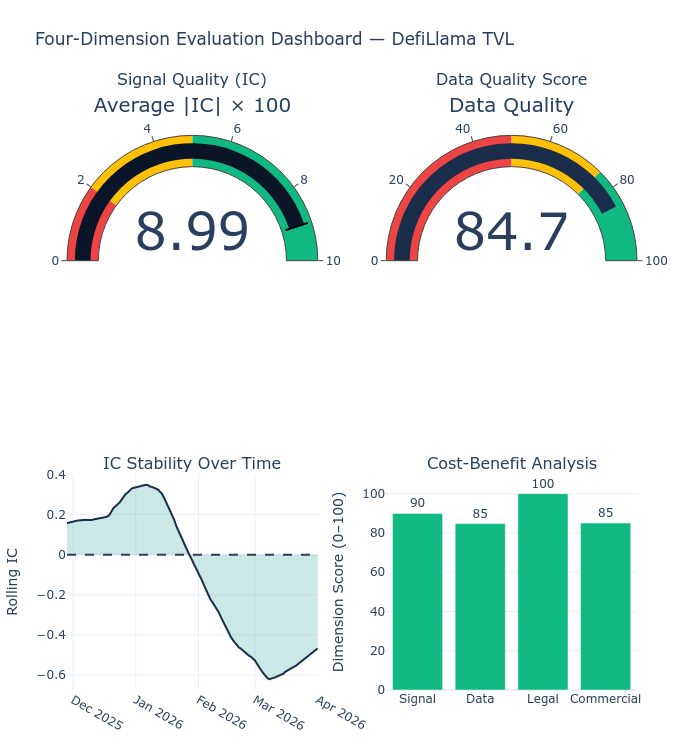

In [17]:
# Build the four-panel dashboard in a SINGLE cell so the inline backend
# does not capture progressive-render intermediates with only the first
# (or first two) gauges populated (feedback_split_cell_figure_bug).
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Signal Quality (IC)",
        "Data Quality Score",
        "IC Stability Over Time",
        "Cost-Benefit Analysis",
    ),
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "scatter"}, {"type": "bar"}],
    ],
    vertical_spacing=0.28,
    horizontal_spacing=0.12,
)

# Signal quality gauge
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=avg_ic * 100,  # Convert to percentage for readability
        title={"text": "Average |IC| × 100"},
        gauge={
            "axis": {"range": [0, 10]},
            "bar": {"color": COLORS["blue"]},
            "steps": [
                {"range": [0, 2], "color": COLORS["negative"]},
                {"range": [2, 5], "color": "#FFC107"},
                {"range": [5, 10], "color": COLORS["positive"]},
            ],
            "threshold": {
                "line": {"color": "black", "width": 2},
                "thickness": 0.75,
                "value": avg_ic * 100,
            },
        },
    ),
    row=1,
    col=1,
)

# Data quality gauge
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=quality.score,
        title={"text": "Data Quality"},
        gauge={
            "axis": {"range": [0, 100]},
            "bar": {"color": COLORS["slate"]},
            "steps": [
                {"range": [0, 50], "color": COLORS["negative"]},
                {"range": [50, 75], "color": "#FFC107"},
                {"range": [75, 100], "color": COLORS["positive"]},
            ],
        },
    ),
    row=1,
    col=2,
)

# Rolling IC and cost-benefit panels
fig.add_trace(
    go.Scatter(
        x=rolling_ic_df["timestamp"],
        y=rolling_ic_df["rolling_ic"],
        mode="lines",
        name="Rolling IC",
        line=dict(color=COLORS["slate"], width=2),
        fill="tozeroy",
        fillcolor="rgba(4, 138, 129, 0.2)",
        showlegend=False,
    ),
    row=2,
    col=1,
)
# Add zero line on the rolling-IC subplot. Mixed-spec make_subplots places the
# row=2,col=1 scatter on the primary x/y axes (indicator subplots don't claim
# numbered axes), so reference the first scatter axes directly via "x domain".
fig.add_shape(
    type="line",
    x0=0,
    x1=1,
    y0=0,
    y1=0,
    xref="x domain",
    yref="y",
    line=dict(dash="dash", color=COLORS["neutral"]),
)

risk_to_score = {"Low": 100, "Medium": 50, "High": 20, "Critical": 0}
dimension_names = ["Signal", "Data", "Legal", "Commercial"]
dimension_scores = [
    min(100, avg_ic * 1000),
    quality.score,
    risk_to_score[legal["mnpi_risk"]],
    85,  # free data + ~$9k/yr engineering at the median fund size
]
dimension_colors = [
    COLORS["positive"] if s >= 60 else (COLORS["amber"] if s >= 40 else COLORS["negative"])
    for s in dimension_scores
]

fig.add_trace(
    go.Bar(
        x=dimension_names,
        y=dimension_scores,
        marker_color=dimension_colors,
        text=[f"{s:.0f}" for s in dimension_scores],
        textposition="outside",
        showlegend=False,
    ),
    row=2,
    col=2,
)

fig.update_layout(
    height=750,
    title="Four-Dimension Evaluation Dashboard — DefiLlama TVL",
    template="plotly_white",
    margin=dict(t=90, b=60, l=60, r=60),
)
# Force the rolling-IC subplot (row=2, col=1) x-axis to render as datetime.
# In mixed-spec make_subplots (indicator + scatter + bar) the subplot xaxis can
# default to numeric epoch ticks when traces are added before the layout pass;
# the explicit type+range below pins it to the actual data window.
_ts_min = rolling_ic_df["timestamp"].min()
_ts_max = rolling_ic_df["timestamp"].max()
fig.update_xaxes(type="date", range=[_ts_min, _ts_max], row=2, col=1)
fig.update_yaxes(title_text="Rolling IC", row=2, col=1)
fig.update_yaxes(title_text="Dimension Score (0–100)", range=[0, 110], row=2, col=2)
fig.show()

### Evidence summary

The framework records measurements; it does not declare a single answer.
The table below restates the four-dimension findings together with
the most important caveats so a research lead can decide whether to
fund a TVL prototype or close the file.

In [18]:
evidence_summary = pl.DataFrame(
    {
        "dimension": ["Signal", "Data", "Legal", "Commercial"],
        "headline_metric": [
            f"avg |IC| {avg_ic:.3f}, best |IC| {best_ic:.3f}",
            f"{quality.score:.0f}/100 (coverage {quality.coverage_years:.1f}y, missing {quality.missing_pct:.1%})",
            f"MNPI risk {legal['mnpi_risk']} (public on-chain data)",
            f"~${annual_hours * hourly_rate:,}/yr engineering, $0 data fees",
        ],
        "binding_caveat": [
            f"Rolling IC mean {ic_mean:+.3f}, positive in {ic_positive_pct:.0%} of windows; sign reverses with horizon — likely contrarian rather than directional",
            "No point-in-time vintages — historical revisions can backfill, inflating any backtest",
            "Crypto regulation varies by jurisdiction; institutional deployment requires compliance review of underlying smart-contract exposure",
            f"Required alpha at small fund (10% allocation, 3× ROI) is {cost_table.filter(pl.col('fund_size') == 'Small ($10M)')['required_alpha_bps'].item():.1f} bps — small funds carry the cost-recovery burden",
        ],
    }
)
evidence_summary

dimension,headline_metric,binding_caveat
str,str,str
"""Signal""","""avg |IC| 0.090, best |IC| 0.27…","""Rolling IC mean -0.110, positi…"
"""Data""","""85/100 (coverage 7.3y, missing…","""No point-in-time vintages — hi…"
"""Legal""","""MNPI risk Low (public on-chain…","""Crypto regulation varies by ju…"
"""Commercial""","""~$9,000/yr engineering, $0 dat…","""Required alpha at small fund (…"


Reading this evidence:

- The **signal** dimension passes the screening bar in magnitude
  (`avg |IC|` exceeds 0.05) but the rolling-window analysis shows it
  is regime-dependent and the sign flips with horizon, which is
  characteristic of mean-reverting rather than directional alpha. A
  prototype should test a *reversal* specification before a momentum
  one.
- The **data** dimension scores well on coverage and completeness but
  fails on point-in-time availability — the binding limitation for
  any production backtest. Either build a snapshot archive going
  forward or accept that historical performance may be optimistic.
- The **legal** dimension is clean for the DefiLlama feed itself; the
  institutional friction is downstream compliance review of the
  underlying smart-contract exposure, not the data acquisition.
- The **commercial** dimension is permissive at scale but punishing
  at small AUM; the break-even calculation should drive whether the
  project even starts.

None of these dimensions is decisive in isolation. Combine them with
the strategy hypothesis and the fund's research-budget constraints
before committing to a prototype.

---

## Key Takeaways

1. **The IC matrix shows horizon-dependent sign flips.** The TVL
   z-score reaches IC = -0.28 at the 60-day horizon over the joined
   window — strong in magnitude but consistent with mean reversion,
   not directional alpha. The 30-day TVL growth signal peaks around
   the 14-day horizon and decays past 60 days.
2. **Rolling IC stability is the discriminator.** A point estimate
   near 0.10 is uninformative when the rolling 180-day mean sits
   close to zero (and turns negative in segments) while the share of
   positive windows hovers around 50% — record point IC, rolling
   mean, and the share-positive together, never just the headline.
3. **Composite scores are scaffolds.** The data-quality 0-100 score is
   only meaningful relative to other datasets scored with the same
   rubric; the binding constraint here is the absence of point-in-time
   vintages, not the headline number.
4. **Legal clearance is necessary but not sufficient.** Public on-chain
   data clears MNPI; institutional deployment still requires a
   compliance review of the underlying smart-contract exposure.
5. **Cost recovery scales with AUM.** Free data still costs roughly
   \$9,000/year in engineering; small funds need three-digit basis
   points of alpha to justify it, large funds need single digits.

## Applying This Framework

The same workflow applies to any alt-data candidate:

1. Load real history; never theorise about availability.
2. Compute signal magnitude *and* stability (point IC + rolling IC + sign behaviour vs horizon).
3. Score data quality on the same axes, treating the composite as relative.
4. Document the legal posture, including downstream compliance
   constraints, not just data acquisition.
5. Compute break-even alpha at the relevant fund size.
6. Surface the four-dimension evidence to the research lead — let
   them combine it with the strategy hypothesis to make the call.